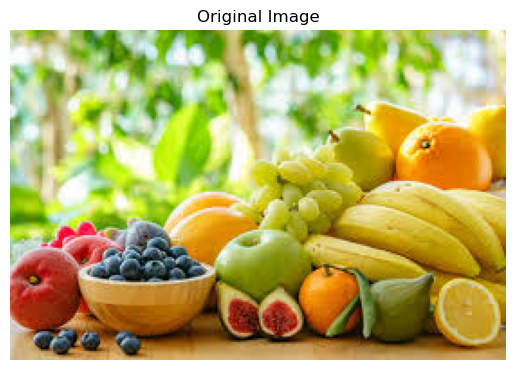

In [6]:
#Exercise 1 - Basic Image Processing
#SUvina Thapa
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

#Loading image
fruit_image = Image.open("fruit_image.jpg")

#Display image
plt.imshow(fruit)
plt.title("Original Image")
plt.axis("off")
plt.show()

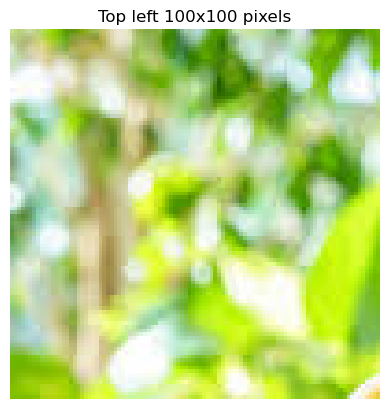

In [8]:
#Converting image to nump array
image_array = np.array(fruit_image)

#to extraxt top left pixel
top_left = image_array[0:100, 0:100]

#Displaying
plt.imshow(top_left)
plt.title("Top left 100x100 pixels")
plt.axis("off")
plt.show()

(-0.5, 274.5, 182.5, -0.5)

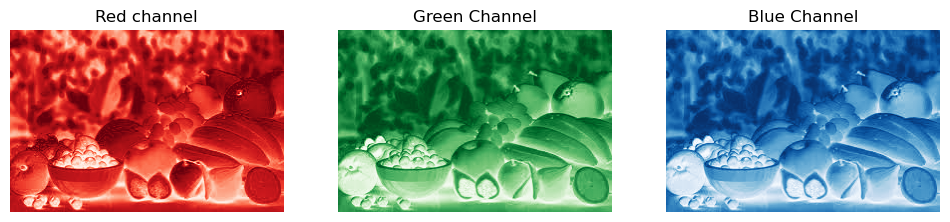

In [13]:
#Showing RGB channels
red = image_array[:, :, 0]
green = image_array[:, :, 1]
blue = image_array[:, :, 2]

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(red, cmap='Reds')
plt.title("Red channel")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(green, cmap='Greens')
plt.title("Green Channel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(green, cmap='Blues')
plt.title("Blue Channel")
plt.axis("off")



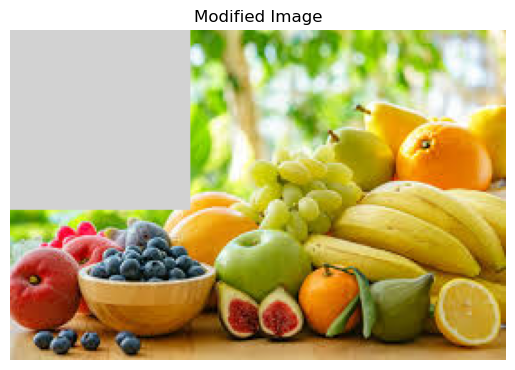

In [14]:
#Modifying Top 100x100 pixel into 210
modified_image = image_array.copy()
#setting top-left 100x100 pixel to 210
modified_image[0:100, 0:100] = 210
#Display
plt.imshow(modified_image)
plt.title("Modified Image")
plt.axis("off")
plt.show()

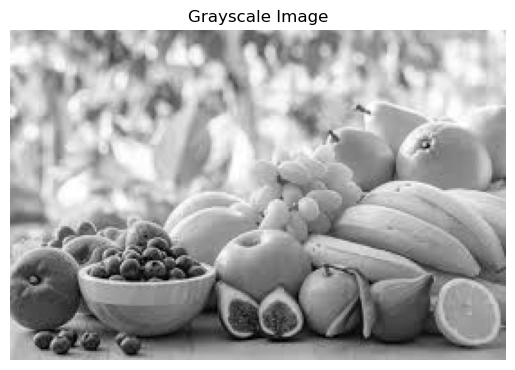

In [15]:
#Exercise 2
#Loading and Dsiaplying Grayscale image
gray_image = Image.open("fruit_image.jpg").convert("L")
gray_array = np.array(gray_image)

plt.imshow(gray_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

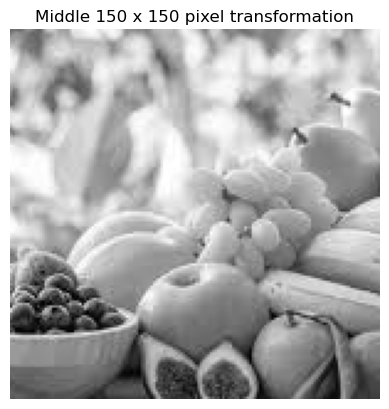

In [16]:
#Extracting Middle Section
h,w = gray_array.shape

center_h = h // 2
center_w = w // 2

cropped = gray_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.imshow(cropped, cmap='gray')
plt.title("Middle 150 x 150 pixel transformation")
plt.axis("off")
plt.show()

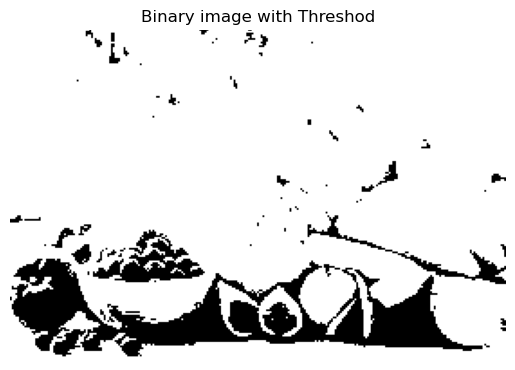

In [17]:
# Aplling threshold
binary_image = gray_array.copy()
binary_image[binary_image < 100] = 0
binary_image[binary_image >= 100] = 255

plt.imshow(binary_image, cmap='gray')
plt.title("Binary image with Threshod")
plt.axis("off")
plt.show()


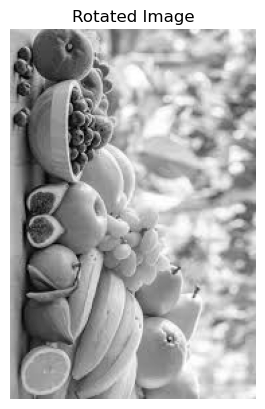

In [18]:
#Image rotation 90 clockwise
rotated = gray_image.rotate(-90, expand=True)

plt.imshow(rotated, cmap='gray')
plt.title("Rotated Image")
plt.axis("off")
plt.show()

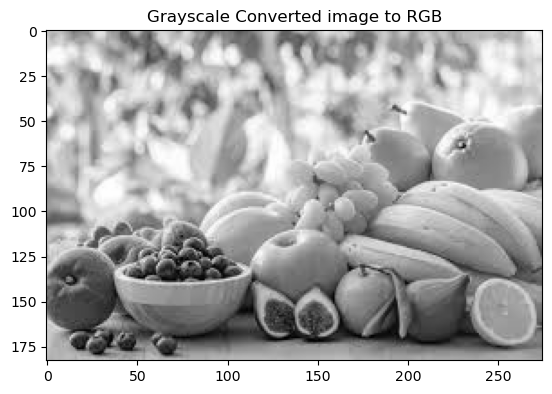

(183, 275)
(183, 275, 3)


In [21]:
#Converting grayscale to rgb
rgb_image = gray_image.convert("RGB")
plt.imshow(rgb_image)
plt.title("Grayscale Converted image to RGB")
plt.axis()
plt.show()
print(np.array(gray_image).shape)
print(np.array(rgb_image).shape)


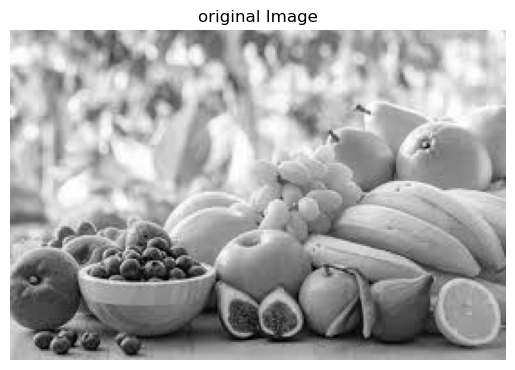

In [23]:
#Exercise 3
# PCA Image COmpression
#Load and prepare data
fruit_image = Image.open("fruit_image.jpg").convert("L")
image_array = np.array(fruit_image)
plt.imshow(image_array, cmap='gray')
plt.title("original Image")
plt.axis("off")
plt.show()
height,width = image_array.shape
data = image_array.reshape(height,width)

In [24]:
#STanfardize data
mean = np.mean(data,axis=0)
centered_data = data - mean

In [25]:
#Covariance Matrix
cov_matrix = np.cov(centered_data, rowvar=False)

In [26]:
#Eigenvalues and Eigen vectors
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
#sortting descending
sorted_index = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

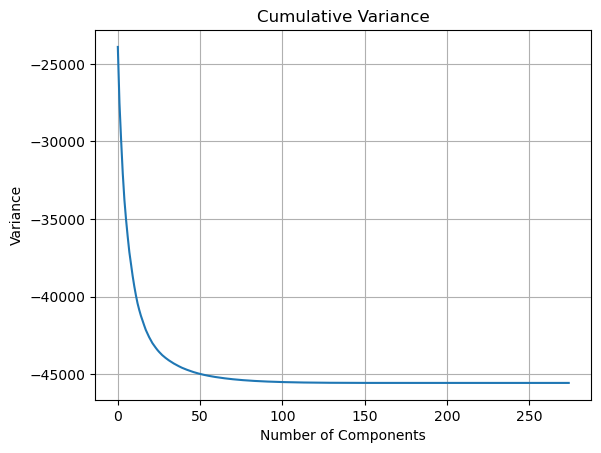

In [29]:
#Variance PLot
variance = eigenvalues / np.sum(eigenvectors)

plt.plot(np.cumsum(variance))
plt.title("Cumulative Variance")
plt.xlabel("Number of Components")
plt.ylabel("Variance")
plt.grid(True)
plt.show()

In [30]:
#Principal COmponents
k = 50
components = eigenvectors[:,:k]


In [31]:
#Image compress
compressed_data = np.dot(centered_data, components)


In [32]:
#Reconstruct Image
reconstructed = np.dot(compressed_data, components.T) + mean


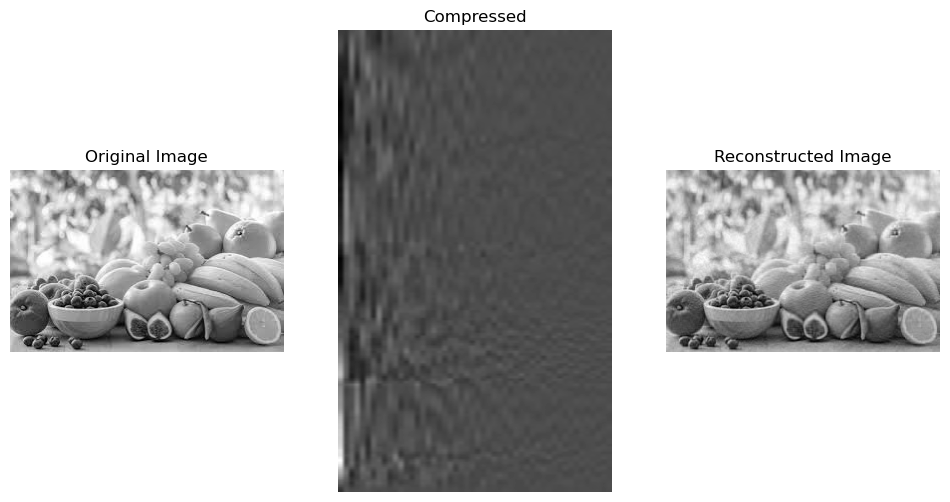

In [33]:
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(image_array, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(compressed_data, cmap='gray', aspect='auto')
plt.title("Compressed")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(reconstructed, cmap='gray')
plt.title("Reconstructed Image")
plt.axis("off")

plt.show()